# Prediction of Concrete Compressive Strength

## Data Pre - Processing

### Import Libraries


In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import copy , math

### Import Dataset

In [2]:
dataset = pd.read_csv('Concrete_Data.csv')
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:,-1].values

In [3]:
print(x)

[[ 540.     0.     0.  ... 1040.   676.    28. ]
 [ 540.     0.     0.  ... 1055.   676.    28. ]
 [ 332.5  142.5    0.  ...  932.   594.   270. ]
 ...
 [ 148.5  139.4  108.6 ...  892.4  780.    28. ]
 [ 159.1  186.7    0.  ...  989.6  788.9   28. ]
 [ 260.9  100.5   78.3 ...  864.5  761.5   28. ]]


In [4]:
print(y)

[79.98611076 61.88736576 40.26953526 ... 23.69660064 32.76803638
 32.40123514]


### Clean the data

#### Handle Missing Data

In [5]:
# Check for missing values
print(dataset.isnull().sum())

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64


<b><i>There is no missing values</i></b>

### Test Train Split

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2 , random_state = 1)

In [7]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(824, 8)
(206, 8)
(824,)
(206,)


### Feature Scaling

In [8]:
# Convert x to a DataFrame for easier manipulation
x_df = pd.DataFrame(x, columns=dataset.columns[:-1])

# Calculate the min and max for each feature
min_values = x_df.min()
max_values = x_df.max()

# Print min and max values in a suitable way
for column in x_df.columns:
    print(f"Feature: {column}")
    print(f"Min value: {min_values[column]}")
    print(f"Max value: {max_values[column]}")
    print("-" * 30)

Feature: Cement (component 1)(kg in a m^3 mixture)
Min value: 102.0
Max value: 540.0
------------------------------
Feature: Blast Furnace Slag (component 2)(kg in a m^3 mixture)
Min value: 0.0
Max value: 359.4
------------------------------
Feature: Fly Ash (component 3)(kg in a m^3 mixture)
Min value: 0.0
Max value: 200.1
------------------------------
Feature: Water  (component 4)(kg in a m^3 mixture)
Min value: 121.75
Max value: 247.0
------------------------------
Feature: Superplasticizer (component 5)(kg in a m^3 mixture)
Min value: 0.0
Max value: 32.2
------------------------------
Feature: Coarse Aggregate  (component 6)(kg in a m^3 mixture)
Min value: 801.0
Max value: 1145.0
------------------------------
Feature: Fine Aggregate (component 7)(kg in a m^3 mixture)
Min value: 594.0
Max value: 992.6
------------------------------
Feature: Age (day)
Min value: 1.0
Max value: 365.0
------------------------------


<i>all features need to be scale</i>

In [9]:
#standaditation training set
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)

In [10]:
print(x_train)

[[-0.02458038 -0.83693595 -0.84928337 ... -0.07197232  1.01034984
  -0.27431532]
 [ 0.76070485 -0.61436309  1.34588042 ... -0.40831547  0.30789145
  -0.68721139]
 [-0.0648023   1.29390636 -0.84928337 ...  0.50239829 -0.79943842
  -0.27431532]
 ...
 [-1.32413166  1.64650863 -0.84928337 ... -0.02281447 -0.36263702
   0.74966693]
 [-1.38446455 -0.83693595  1.73509386 ... -0.16252624  0.35897933
  -0.27431532]
 [-0.63020767  0.31177431 -0.46754283 ...  1.19578263  0.11018134
  -0.50553712]]


In [11]:
#standaditation training set  seperately
x_test = sc.fit_transform(x_test)

In [12]:
print(x_test)

[[ 0.09198106 -0.94074758  1.03091052 ...  0.66157143 -0.08005318
  -0.64713914]
 [-0.47445336 -0.94074758  0.65821389 ... -0.25761658  1.00989968
  -0.64713914]
 [-1.41403881  0.55417495  0.79962545 ... -0.68524267 -0.08529557
  -0.30198933]
 ...
 [ 0.68457631 -0.72718722  1.40408435 ... -0.35736657  0.47389358
  -0.59191517]
 [ 0.21502315 -0.94074758 -0.83877629 ... -0.00426925  1.04473251
   0.5539822 ]
 [ 0.4306343   0.66095514 -0.83877629 ... -0.48347276 -1.93760964
   1.79652151]]


## Train the model using Linear Regression

### Build the model

In [8]:
b_init = 35
w_init = np.random.uniform(0.001, 0.005, (8))

In [9]:
def predict_single(x, w, b):
    p = np.dot(w,x) + b
    return p

In [10]:
x_vec = x_train[0,:]
f_wp_vec = predict_single(x_vec,w_init,b_init)
f_wp_vec

40.16735896290922

In [11]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb = np.dot(w,x[i]) + b 
        err = f_wb - y[i]
        cost = cost + (err**2)
    cost = cost/(2*m)
    return cost

In [12]:
def compute_gradient(x,y,w,b):
    m,n = x.shape
    dj_dw = np.zeros((n,))
    dj_db = 0
    for i in range(m):
        err = (np.dot(w,x[i]) + b) - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err*x[i,j]
        dj_db = dj_db + err
        dj_dw = dj_dw / m                                
    dj_db = dj_db / m                                
        
    return dj_db, dj_dw


In [13]:
tmp_dj_db, tmp_dj_dw = compute_gradient(x_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: 4.772519774022895
dj_dw at initial w,b: 
 [ 5.74732966  2.63411442  0.66511889  4.88894982  0.17902302 28.67255693
 21.13215973  0.37716077]


In [14]:
def gradient_descent(x,y,w_in,b_in , cost_function , gradient_function, alpha, num_iters):
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in
    for i in range(num_iters):
        dj_db , dj_dw = gradient_function(x,y,w,b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(x, y, w, b))
    if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")

    return w, b, J_history

### Make Predictions

In [15]:
initial_w = np.zeros_like(w_init)
initial_b = 35
iterations = 1000
alpha = 5.0e-2
w_final, b_final, J_hist = gradient_descent(x_train, y_train, initial_w, initial_b,compute_cost, compute_gradient,alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")

b,w found by gradient descent: 35.02,[-0.22283816 -0.10212545 -0.02580194 -0.18956253 -0.00694169 -1.1117318
 -0.81937391 -0.01462516] 


In [35]:
m,_ = x_test.shape
for i in range(m):
    print(f"prediction: {predict_single(x_test[i], w_final, b_final)}, target value: {y_test[i]}")

prediction: 35.02005433136331, target value: 21.91154728
prediction: 35.02055829667397, target value: 19.93275116
prediction: 35.020358764834775, target value: 36.4388066
prediction: 35.01741000710348, target value: 11.957582268
prediction: 35.022329913802395, target value: 39.84481804
prediction: 35.01888923284341, target value: 66.9481196
prediction: 35.01887620894352, target value: 21.179323768
prediction: 35.022261382755765, target value: 52.1243856
prediction: 35.02004171759919, target value: 39.056057496
prediction: 35.018451394320586, target value: 21.819846972
prediction: 35.01964118326639, target value: 39.2311844
prediction: 35.01906130253483, target value: 15.0305768
prediction: 35.01972456859637, target value: 25.10382116
prediction: 35.02112722625711, target value: 26.96540636
prediction: 35.01741238339237, target value: 10.335934716
prediction: 35.01802228341783, target value: 26.8550902
prediction: 35.02163365821846, target value: 38.407950056
prediction: 35.020183524612

### Evaluate the model

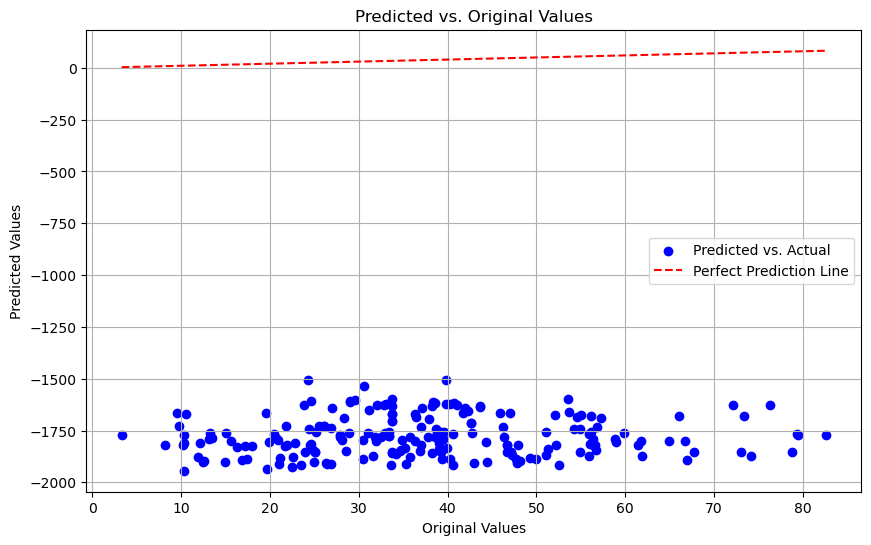

In [16]:
predictions = np.array([np.dot(x_test[i], w_final) + b_final for i in range(x_test.shape[0])])
target_values = np.array(y_test)

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(target_values, predictions, color='blue', label='Predicted vs. Actual')
plt.plot([min(target_values), max(target_values)], [min(target_values), max(target_values)], color='red', linestyle='--', label='Perfect Prediction Line')
plt.title('Predicted vs. Original Values')
plt.xlabel('Original Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid()
plt.show()

In [17]:
# 1. Generate predictions for the test set
def predict(x, w, b):
    return np.dot(x, w) + b




In [18]:
# 2. Calculate Mean Squared Error on test data
def mean_squared_error(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    return mse


In [19]:

# 3. Calculate R² score on test data
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2


In [62]:
# Initialize parameters and hyperparameters
initial_w = np.zeros_like(w_init)  # Starting weight as zero array, same shape as w_init
initial_b = 0.0                    # Starting bias
iterations = 500                 # Number of iterations
alpha = 5.0e-2                     # Learning rate

# Run gradient descent to find optimal w and b
w_final, b_final, J_hist = gradient_descent(x_train, y_train, initial_w, initial_b, compute_cost, compute_gradient, alpha, iterations)
print(f"b, w found by gradient descent: {b_final:.2f}, {np.array2string(w_final, precision=2)}")






C:\Users\User\AppData\Local\Temp\ipykernel_17048\2873492534.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dj_dw[j] += err * x[i, j]  # Update each weight individually


Iteration    0: Cost   697.88
Iteration   50: Cost    59.38
Iteration  100: Cost    54.21
Iteration  150: Cost    53.51
Iteration  200: Cost    53.13
Iteration  250: Cost    52.88
Iteration  300: Cost    52.69
Iteration  350: Cost    52.54
Iteration  400: Cost    52.42
Iteration  450: Cost    52.32


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [20]:
# Now, generate predictions on the test set
y_pred_test = predict(x_test, w_final, b_final)

# Check performance with Mean Squared Error and R² Score (as outlined previously)
mse_test = mean_squared_error(y_test, y_pred_test)
print(f"Mean Squared Error on test data: {mse_test:.2f}")

r2_test = r_squared(y_test, y_pred_test)
print(f"R² score on test data: {r2_test:.2f}")

# Optional: Print predictions vs actual values for test set
for i in range(len(x_test)):
    print(f"Prediction: {y_pred_test[i]:0.2f}, Target: {y_test[i]}")


Mean Squared Error on test data: 3297459.74
R² score on test data: -12647.66
Prediction: -1821.91, Target: 21.91154728
Prediction: -1805.99, Target: 19.93275116
Prediction: -1686.12, Target: 36.4388066
Prediction: -1878.09, Target: 11.957582268
Prediction: -1504.69, Target: 39.84481804
Prediction: -1890.82, Target: 66.9481196
Prediction: -1882.59, Target: 21.179323768
Prediction: -1676.04, Target: 52.1243856
Prediction: -1809.78, Target: 39.056057496
Prediction: -1730.47, Target: 21.819846972
Prediction: -1851.70, Target: 39.2311844
Prediction: -1762.02, Target: 15.0305768
Prediction: -1853.97, Target: 25.10382116
Prediction: -1639.21, Target: 26.96540636
Prediction: -1943.88, Target: 10.335934716
Prediction: -1736.25, Target: 26.8550902
Prediction: -1612.17, Target: 38.407950056
Prediction: -1819.75, Target: 56.63355864
Prediction: -1852.59, Target: 67.69964844
Prediction: -1822.07, Target: 36.9903874
Prediction: -1903.73, Target: 24.98661024
Prediction: -1840.81, Target: 51.25564584


In [50]:

# Calculate the Mean Squared Error (MSE) for test set
mse_test = mean_squared_error(y_test, y_pred_test)
print(f"Mean Squared Error on test data: {mse_test:.2f}")

# Calculate the R² score for test set
r2_test = r_squared(y_test, y_pred_test)
print(f"R² score on test data: {r2_test:.2f}")

# Print predictions vs actual values for test set (optional)
for i in range(len(x_test)):
    print(f"Prediction: {y_pred_test[i]:0.2f}, Target: {y_test[i]}")

NameError: name 'y_pred_test' is not defined

## Train the model using SVM 

### Build the mode

In [ ]:
# code here 

### Train the model

In [ ]:
# code here

### Make Predictions

In [ ]:
# code here

### Evaluate the model

In [ ]:
# code here

## conclusion